In [3]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import os
import warnings
from scipy import stats
from sklearn.cluster import KMeans
from pandas.api.types import CategoricalDtype
from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import mutual_info_regression
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from category_encoders import MEstimateEncoder
import optuna
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

c:\Users\arnov\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# train path:
train_path = "C:/Users/arnov/Desktop/Kaggel/HousingModel/train.csv"
# test path:
test_path = "C:/Users/arnov/Desktop/Kaggel/HousingModel/test.csv"
# load train data:
train = pd.read_csv(train_path, index_col='Id')
test = pd.read_csv(test_path, index_col='Id')

In [6]:
# Train data:
display(train.head())
print('Train data contains {} rows and {} features'.format(train.shape[0], train.shape[1]))

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Train data contains 1460 rows and 80 features


In [7]:
def clean(df) :
    df["Exterior2nd"] = df["Exterior2nd"].replace({"Brk Cmn": "BrkComm"})
    # Names beginning with numbers are awkward to work with
    df.rename(columns={
        "1stFlrSF": "FirstFlrSF",
        "2ndFlrSF": "SecondFlrSF",
        "3SsnPorch": "Threeseasonporch",
    }, inplace=True,
    )
    # Some values of GarageYrBlt are corrupt, so we'll replace them
    # with the year the house was built
    df["GarageYrBlt"] = df["GarageYrBlt"].where(df.GarageYrBlt <= 2010, df.YearBuilt)
    return df
    
train = clean(train)
test = clean(test)

In [8]:
all_data = pd.concat([train, test])
all_data.tail(10)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
2910,180,RM,21.0,1470,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,NaN
2911,160,RM,21.0,1484,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,NaN
2912,20,RL,80.0,13384,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,NaN
2913,160,RM,21.0,1533,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,12,2006,WD,Abnorml,NaN
2914,160,RM,21.0,1526,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,NaN
2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN


In [9]:
# Vsiualize the percentages of missing values per features:
missing_values = pd.DataFrame({'Percentage' : (all_data.isnull().sum()/len(all_data)) * 100}, 
                              index=all_data.columns)
missing_values = missing_values[missing_values['Percentage']>0].sort_values(
    by='Percentage', 
    ascending=False)
missing_values.drop(index='SalePrice', inplace=True)
missing_values.head(10)

,Percentage
PoolQC,99.657417
MiscFeature,96.402878
Alley,93.216855
Fence,80.438506
MasVnrType,60.500171
FireplaceQu,48.646797
LotFrontage,16.649538
GarageCond,5.447071
GarageQual,5.447071
GarageFinish,5.447071


In [10]:
# Replace Na null values for this features with None:
none_features = ['PoolQC','BsmtQual', 'BsmtCond', 'BsmtExposure', 'FireplaceQu', 'GarageFinish', 
                 'GarageQual', 'GarageCond', 'Fence', 'Alley', 'BsmtFinType1', 'BsmtFinType2', 
                 'MasVnrType', 'GarageType', 'MiscFeature']
for col in none_features:
    all_data[col] = all_data[col].fillna('None')

In [11]:
# Zero imputing missing values:
missing_features_1 = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 
                      'BsmtFullBath', 'BsmtHalfBath','GarageArea', 'GarageCars']
for col in missing_features_1:
    all_data[col] = all_data[col].fillna(0)
# Zero imputing with mode:
missing_features_2 = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 
                      'SaleType']
for col in missing_features_2:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# LotFrontage:
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))
# Functional :
all_data['Functional'] = all_data['Functional'].fillna('Typ')
# Utilities:
all_data.drop('Utilities', axis=1, inplace=True)

In [12]:
# Reform splits
train = all_data.loc[train.index, :]
test = all_data.loc[test.index, :]

In [13]:
def label_encoding(df):
    le = LabelEncoder()
    for col in df.select_dtypes(exclude=['number']).columns:
        df[col] = le.fit_transform(df[col])
    return df

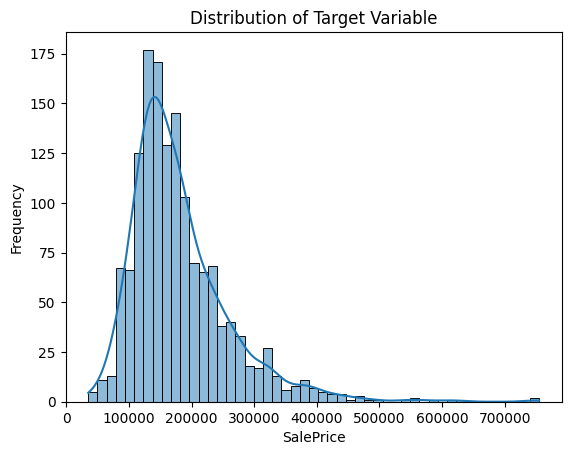

In [14]:
# Distribution of the target variable
sns.histplot(train.SalePrice, kde=True) 
plt.title('Distribution of Target Variable')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

In [15]:
def score_model(X, y, model=XGBRegressor()):
    # Metric for Housing competition is RMSLE (Root Mean Squared Log Error)
    log_y = np.log(y)
    score = cross_val_score(
        model, X, log_y, cv=5, scoring="neg_mean_squared_error",
    )
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score

In [16]:
X = train.copy()
y = X.pop('SalePrice')
X = label_encoding(X)
baseline_score = score_model(X, y)
print(f"Baseline score: {baseline_score:.5f} RMSLE")

Baseline score: 0.14057 RMSLE


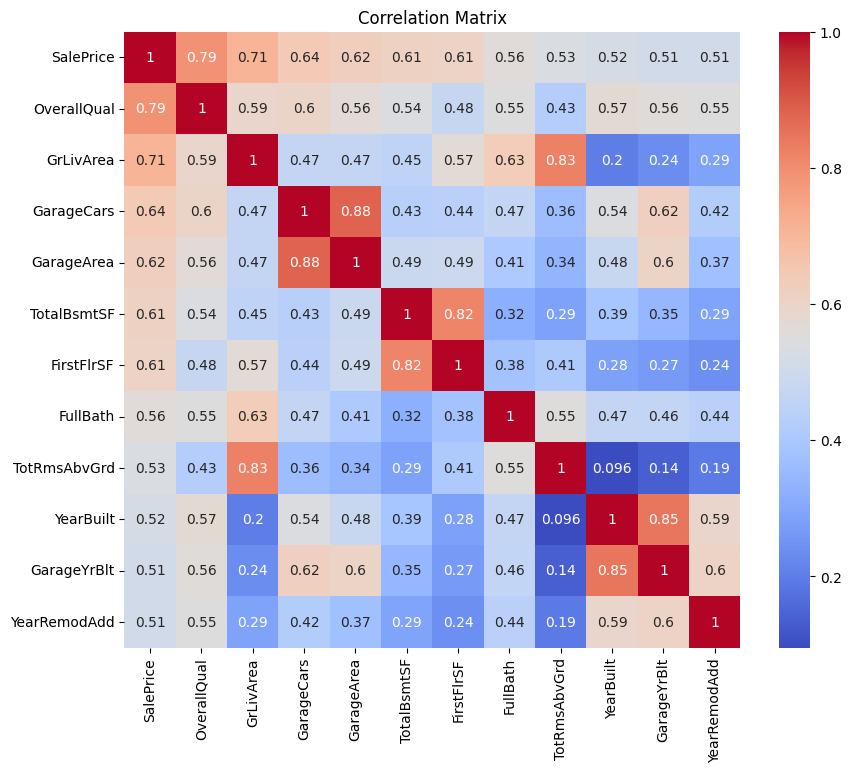

In [17]:
# Calculating correlations :
train_corr = train.select_dtypes(include=[np.number])
# Calculating correlations:
corr = train_corr.corr()
# Sorting correlations with SalePrice:
corr_sorted = corr['SalePrice'].abs().sort_values(ascending=False)
corr_high = corr_sorted[corr_sorted>0.5].index
# Subsetting correlations:
corr = corr.loc[corr_high, corr_high]
# Visualize the heatmap:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

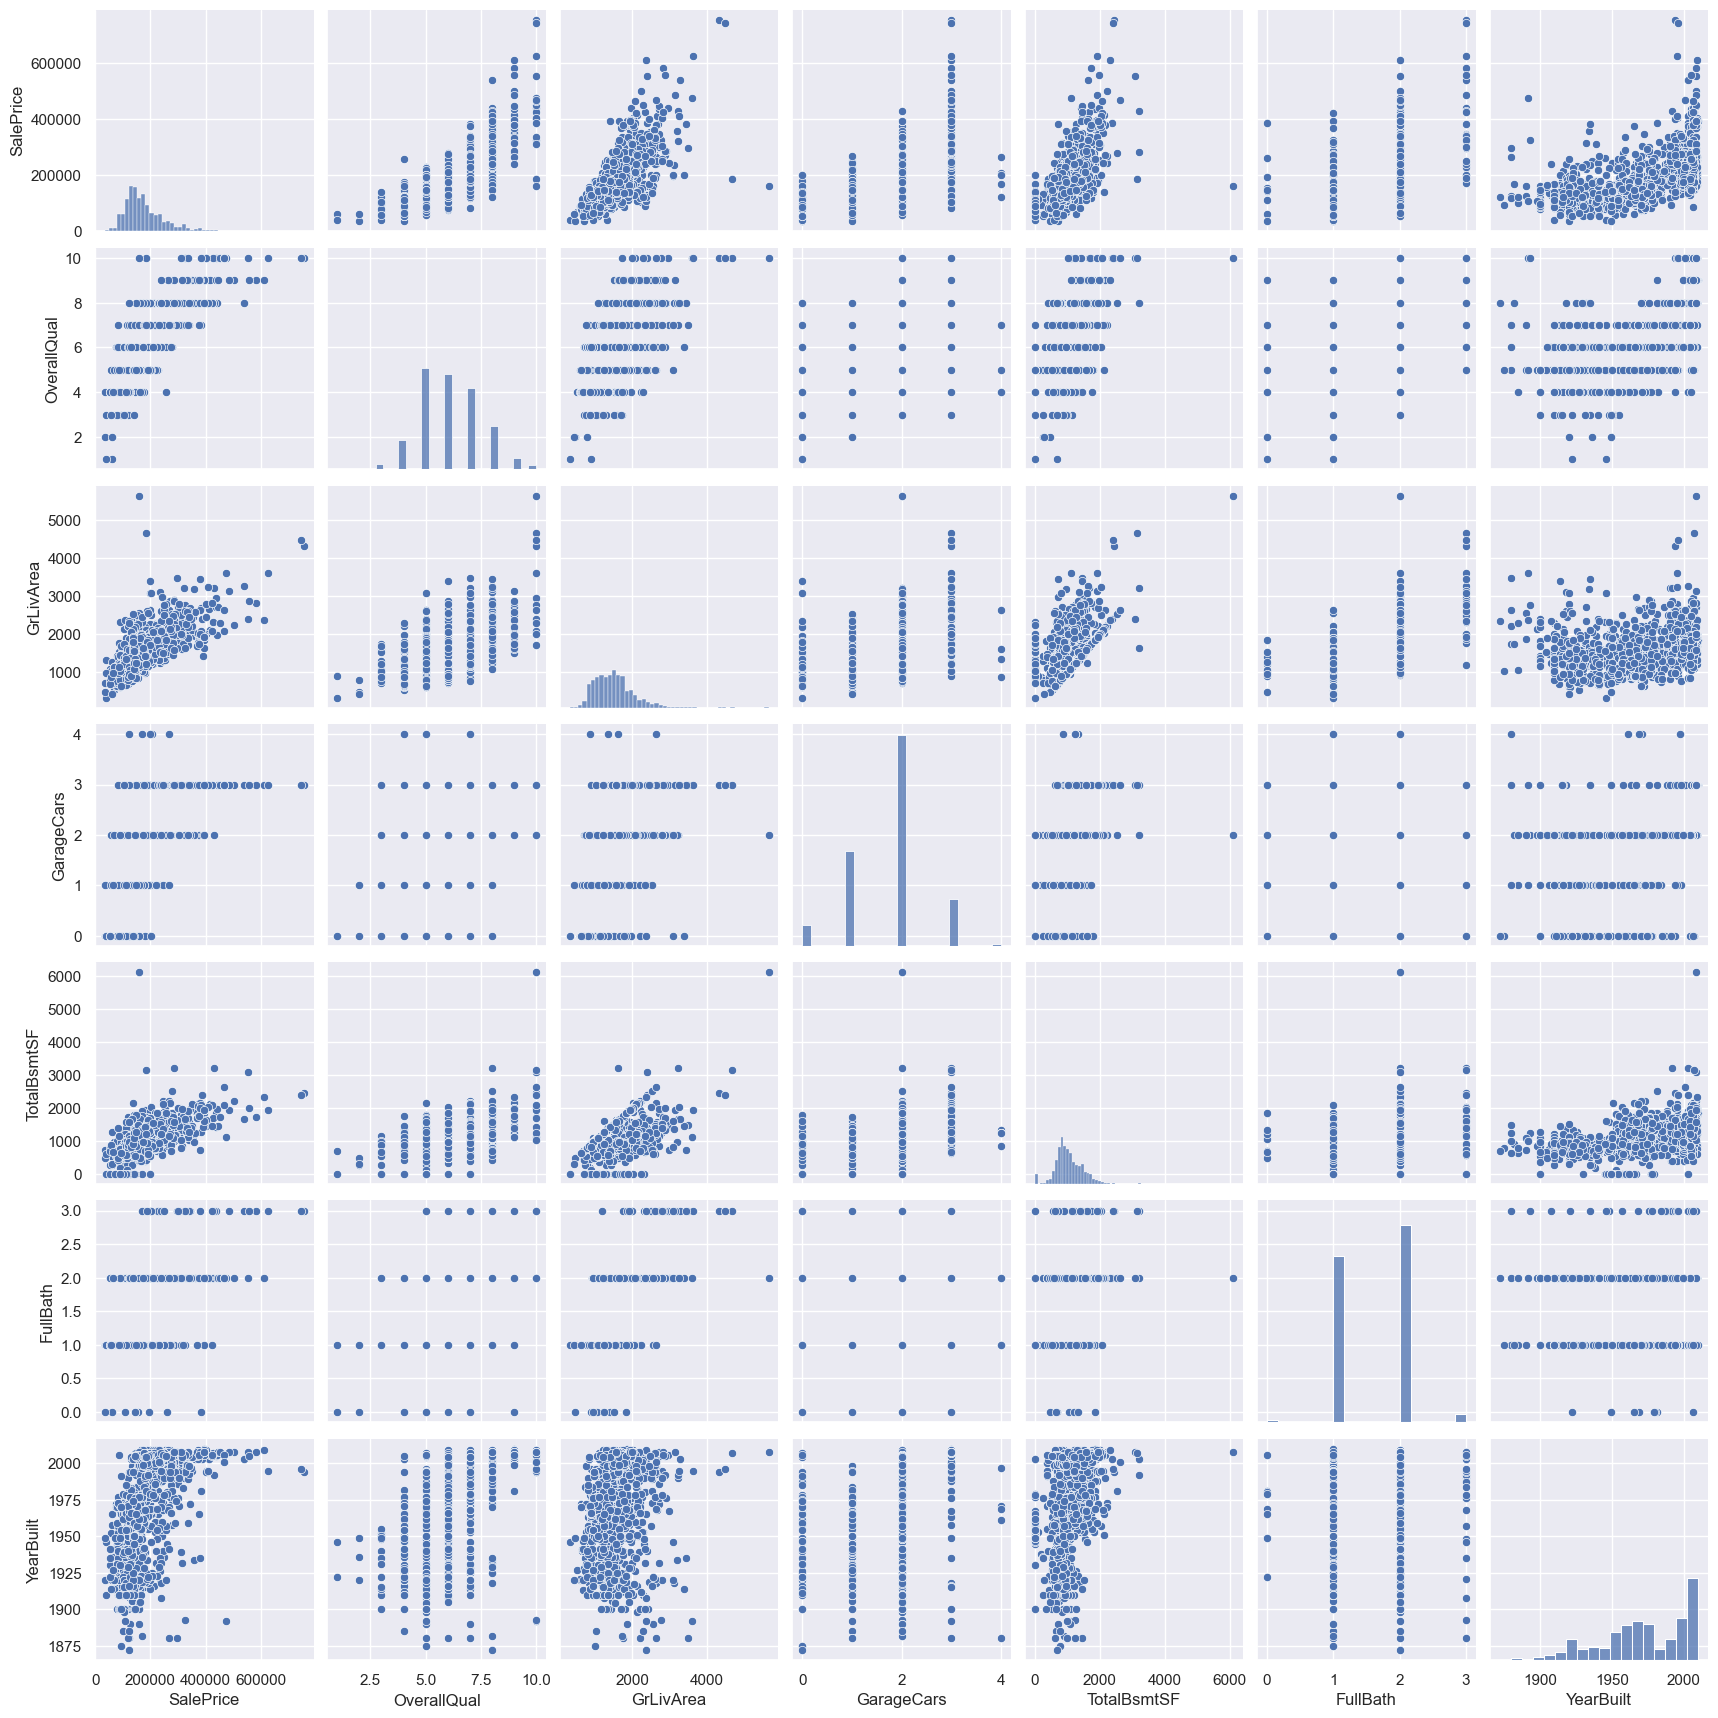

In [18]:
#scatterplot
sns.set()
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train[cols], size = 2.5)
plt.show();

In [19]:
# Function to calculate mi_scores:
def make_mi_scores(X, y):
    X = X.copy()
    # Encode categorical features:
    # All discrete features should now have integer dtypes
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # extract discrete features:
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, 
                                      discrete_features=discrete_features,
                                      random_state=0)
    # Store mi scores in a serie
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    # Sort the mi scores
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [20]:
X = train.copy()
y = X.pop('SalePrice')
scores_mi = make_mi_scores(X, y)
display(scores_mi)

OverallQual     0.571457
Neighborhood    0.526220
GrLivArea       0.430395
YearBuilt       0.407974
LotArea         0.394468
                  ...   
PoolQC          0.000000
MiscFeature     0.000000
MiscVal         0.000000
MoSold          0.000000
YrSold          0.000000
Name: MI Scores, Length: 78, dtype: float64

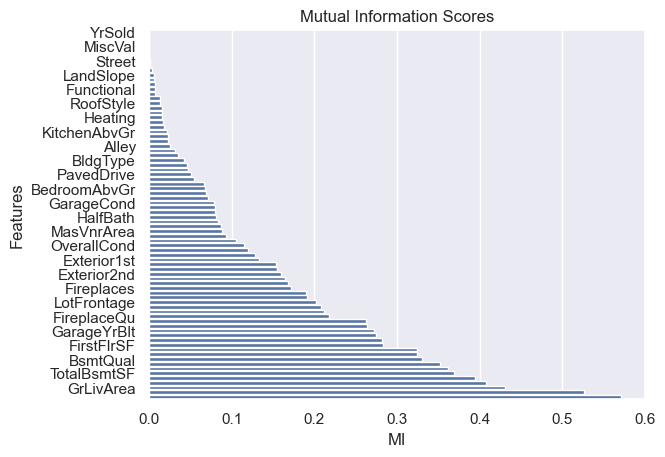

In [21]:
# Function to plot the mi_scores:
def plot_mi_scores(scores):
    # sort the scores:
    scores = scores.sort_values(ascending=True)
    sns.barplot(x=scores, y=scores.index)
    plt.xlabel('MI')
    plt.ylabel('Features')
    plt.title('Mutual Information Scores')
    # Set y-axis tick locations and labels
    tick_locations = range(0, len(scores.index), 3)  # every 2 units
    tick_labels = scores.index[tick_locations]
    plt.yticks(tick_locations, tick_labels)
plot_mi_scores(scores_mi)

In [22]:
# Function to drop uninformative features:
def drop_uninformative(df, mi_scores):
    return df.loc[:, mi_scores > 0.0]

In [23]:
# Score after droping uninformative features:
X = train.copy()
y = X.pop('SalePrice')
X = drop_uninformative(X, scores_mi)
X = label_encoding(X)
score = score_model(X, y)
print(f"Score: {score:.5f} RMSLE")

Score: 0.14088 RMSLE


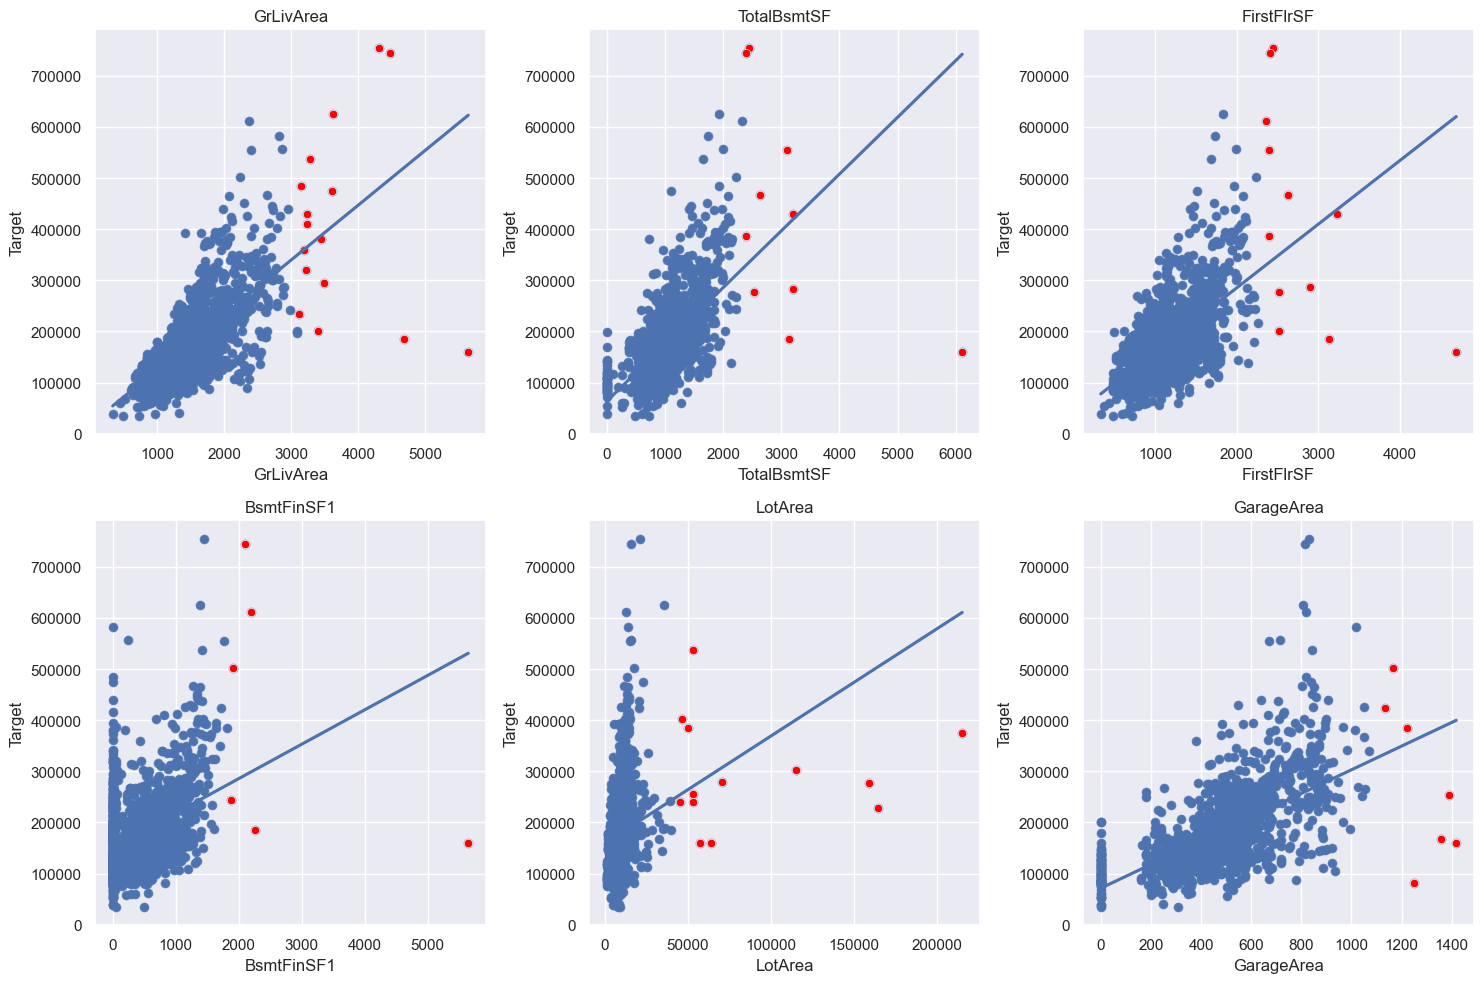

In [24]:
# Define the 6 features
features = ['GrLivArea', 'TotalBsmtSF', 'FirstFlrSF', 'BsmtFinSF1', 'LotArea', 'GarageArea']

# Create a figure and axis object
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Loop through each feature
for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    ax = axs[row, col]
    
    # Create a scatter plot
    sns.scatterplot(x=feature, y='SalePrice', data=train, ax=ax)
    
    # Fit a linear line
    sns.regplot(x=feature, y='SalePrice', data=train, ax=ax, ci=None)
    
    # Identify outliers using Z-score method
    z_scores = np.abs(stats.zscore(train[feature]))
    outliers = train[z_scores > 3]
    
    # Color outliers
    sns.scatterplot(x=feature, y='SalePrice', data=outliers, ax=ax, color='red')
    
    # Set title and labels
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('Target')

# Show the plot
plt.tight_layout()
plt.show()

In [26]:
def delete_outliers(df):
    df = df[df['GrLivArea'] < 4500]
    df = df[df['LotArea'] < 100000]
    df = df[df['TotalBsmtSF'] < 3000]
    df = df[df['FirstFlrSF'] < 2500]
    df = df[df['BsmtFinSF1'] < 2000]
    return df

In [27]:
# Score after deleting outliers:
X = train.copy()
X = delete_outliers(X)
y = X.pop('SalePrice')
X = drop_uninformative(X, scores_mi)
X = label_encoding(X)
score = score_model(X, y)
print(f"Score: {score:.5f} RMSLE")

Score: 0.13694 RMSLE


In [28]:
def mathematical_transforms(df):
    X = pd.DataFrame()  # dataframe to hold new features
    X["LivLotRatio"] = df.GrLivArea / df.LotArea
    X["Spaciousness"] = (df.FirstFlrSF + df.SecondFlrSF) / df.TotRmsAbvGrd
    # This feature ended up not helping performance
    # X["TotalOutsideSF"] = \
    #     df.WoodDeckSF + df.OpenPorchSF + df.EnclosedPorch + \
    #     df.Threeseasonporch + df.ScreenPorch
    return X
def interesting_features(df):
    X= pd.DataFrame()
    X['BsmtFinType1_Unf'] = 1*(df['BsmtFinType1'] == 'Unf')
    X['Total_Home_Quality'] = df['OverallQual'] + df['OverallCond']
    X['TotalSF'] = df['TotalBsmtSF'] + df["FirstFlrSF"] + df["SecondFlrSF"]
    X['YrBltAndRemod'] = df['YearBuilt'] + df['YearRemodAdd']
    X['YearsSinceRemodel'] = df['YrSold'].astype(int) - df['YearRemodAdd'].astype(int)
    X['Total_sqr_footage'] = (df['BsmtFinSF1'] + df['BsmtFinSF2'] + df["FirstFlrSF"] + df["SecondFlrSF"])
    X['Total_Bathrooms'] = (df['FullBath'] + (0.5 * df['HalfBath']) +
                               df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))
    X['haspool'] = df['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
    X['has2ndfloor'] = df['SecondFlrSF'].apply(lambda x: 1 if x > 0 else 0)
    X['hasgarage'] = df['GarageArea'].apply(lambda x: 1 if x > 0 else 0)
    X['hasbsmt'] = df['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
    X['hasfireplace'] = df['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)
    return X
def interactions(df):
    X = pd.get_dummies(df.BldgType, prefix="Bldg")
    X = X.mul(df.GrLivArea, axis=0)
    return X
def counts(df):
    X = pd.DataFrame()
    X["PorchTypes"] = df[[
        "WoodDeckSF",
        "OpenPorchSF",
        "EnclosedPorch",
        "Threeseasonporch",
        "ScreenPorch",
    ]].gt(0.0).sum(axis=1)
    return X
def break_down(df):
    X = pd.DataFrame()
    X["MSClass"] = df.MSSubClass.str.split("_", n=1, expand=True)[0]
    return X
def group_transforms(df):
    X = pd.DataFrame()
    X["MedNhbdArea"] = df.groupby("Neighborhood")["GrLivArea"].transform("median")
    return X

In [29]:
# Score after creating new features:
X = train.copy()
X = delete_outliers(X)
y = X.pop('SalePrice')
X = X.join(interesting_features(X))
X = X.join(mathematical_transforms(X))
X = X.join(interactions(X))
X = X.join(counts(X))
X = X.join(group_transforms(X))
X = label_encoding(X)
score = score_model(X, y)
print(f"Score: {score:.5f} RMSLE")

Score: 0.13128 RMSLE


In [30]:
cluster_features = [
    "LotArea",
    "TotalBsmtSF",
    "FirstFlrSF",
    "SecondFlrSF",
    "GrLivArea",
]


def cluster_labels(df, features, n_clusters=20):
    X = df.copy()
    X_scaled = X.loc[:, features]
    X_scaled = (X_scaled - X_scaled.mean(axis=0)) / X_scaled.std(axis=0)
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=0)
    X_new = pd.DataFrame()
    X_new["Cluster"] = kmeans.fit_predict(X_scaled)
    return X_new


def cluster_distance(df, features, n_clusters=20):
    X = df.copy()
    X_scaled = X.loc[:, features]
    X_scaled = (X_scaled - X_scaled.mean(axis=0)) / X_scaled.std(axis=0)
    kmeans = KMeans(n_clusters=20, n_init=50, random_state=0)
    X_cd = kmeans.fit_transform(X_scaled)
    # Label features and join to dataset
    X_cd = pd.DataFrame(
        X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])]
    )
    return X_cd

In [31]:
# Score after creating new features:
X = train.copy()
X = delete_outliers(X)
y = X.pop('SalePrice')
X = X.join(interesting_features(X))
X = X.join(mathematical_transforms(X))
X = X.join(interactions(X))
X = X.join(counts(X))
X = X.join(group_transforms(X))
X = X.join(cluster_labels(X, cluster_features, n_clusters=20))
X = label_encoding(X)
score = score_model(X, y)
print(f"Score: {score:.5f} RMSLE")

Score: 0.13077 RMSLE


In [32]:
# Apply pca to a df:
def apply_pca(X, standarize=True):
    # Standarize the features for applying pca if you need:
    if standarize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create a pca:
    pca = PCA()
    # fit and transform the features:
    X_pca = pca.fit_transform(X)
    # Convert X_pca to df:
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names) 
    # Create Loading :
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [33]:
# Function to return the pca components of some features: 
def pca_components(df, features):
    X = df.loc[:, features]
    _, X_pca, _ = apply_pca(X)
    return X_pca

In [34]:
# Score after creating PCA components:
X = train.copy()
X = delete_outliers(X)
y = X.pop('SalePrice')
X = X.join(interesting_features(X))
X = X.join(mathematical_transforms(X))
X = X.join(interactions(X))
X = X.join(counts(X))
X = X.join(group_transforms(X))
pca_features = [
    "GarageArea",
    "YearRemodAdd",
    "TotalBsmtSF",
    "GrLivArea",
]
X = X.join(pca_components(X, pca_features))
X = label_encoding(X)
score = score_model(X, y)
print(f"Score: {score:.5f} RMSLE")

Score: 0.13295 RMSLE


In [35]:
# Lets identify the features with the high cardinality variables :
nominal_features = ["MSSubClass", "MSZoning", "Street", "Alley", "LotConfig", "Neighborhood", 
                    "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", 
                    "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", 
                    "CentralAir", "GarageType", "MiscFeature", "SaleType", "SaleCondition"]
cardinality = train[nominal_features].nunique().sort_values(ascending=False)
print(cardinality)

Neighborhood     25
Exterior2nd      16
MSSubClass       15
Exterior1st      15
SaleType          9
Condition1        9
HouseStyle        8
RoofMatl          8
Condition2        8
GarageType        7
RoofStyle         6
Foundation        6
Heating           6
SaleCondition     6
BldgType          5
MSZoning          5
LotConfig         5
MiscFeature       5
MasVnrType        4
Alley             3
CentralAir        2
Street            2
dtype: int64


In [36]:
class CrossFoldEncoder:
    def __init__(self, encoder, **kwargs):
        self.encoder_ = encoder
        self.kwargs_ = kwargs  # keyword arguments for the encoder
        self.cv_ = KFold(n_splits=5)

    # Fit an encoder on one split and transform the feature on the
    # other. Iterating over the splits in all folds gives a complete
    # transformation. We also now have one trained encoder on each
    # fold.
    def fit_transform(self, X, y, cols):
        self.fitted_encoders_ = []
        self.cols_ = cols
        X_encoded = []
        for idx_encode, idx_train in self.cv_.split(X):
            fitted_encoder = self.encoder_(cols=cols, **self.kwargs_)
            fitted_encoder.fit(
                X.iloc[idx_encode, :], y.iloc[idx_encode],
            )
            X_encoded.append(fitted_encoder.transform(X.iloc[idx_train, :])[cols])
            self.fitted_encoders_.append(fitted_encoder)
        X_encoded = pd.concat(X_encoded)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded

    # To transform the test data, average the encodings learned from
    # each fold.
    def transform(self, X):
        from functools import reduce

        X_encoded_list = []
        for fitted_encoder in self.fitted_encoders_:
            X_encoded = fitted_encoder.transform(X)
            X_encoded_list.append(X_encoded[self.cols_])
        X_encoded = reduce(
            lambda x, y: x.add(y, fill_value=0), X_encoded_list
        ) / len(X_encoded_list)
        X_encoded.columns = [name + "_encoded" for name in X_encoded.columns]
        return X_encoded

In [37]:
encoder = CrossFoldEncoder(MEstimateEncoder, m=1)
X_encoded = encoder.fit_transform(X, y, cols=["MSSubClass"])
X_encoded.head()

,MSSubClass_encoded
Id,
1,237921.022113
2,180993.404066
3,237921.022113
4,166597.420056
5,237921.022113


In [38]:
def create_features(df, df_test=None):
    X = df.copy()
    y = X.pop("SalePrice")
    mi_scores = make_mi_scores(X, y)
    if df_test is not None:
        X_test = df_test.copy()
        X_test.pop("SalePrice")
        X = pd.concat([X, X_test])

    # Mutual Information
    # X = drop_uninformative(X, mi_scores)

    # Transformations
    X = X.join(interesting_features(X))
    X = X.join(mathematical_transforms(X))
    X = X.join(interactions(X))
    X = X.join(counts(X))
    # X = X.join(break_down(X))
    X = X.join(group_transforms(X))

    # Clustering
    # X = X.join(cluster_labels(X, cluster_features, n_clusters=20))
    # X = X.join(cluster_distance(X, cluster_features, n_clusters=20))

    # PCA
    # X = X.join(pca_components(X, pca_features))
    # X = X.join(indicate_outliers(X))

    X = label_encoding(X)

    # Reform splits
    if df_test is not None:
        X_test = X.loc[df_test.index, :]
        X.drop(df_test.index, inplace=True)

    # Lesson 6 - Target Encoder
    encoder = CrossFoldEncoder(MEstimateEncoder, m=1)
    X = X.join(encoder.fit_transform(X, y, cols=["Neighborhood"]))
    if df_test is not None:
        X_test = X_test.join(encoder.transform(X_test))

    if df_test is not None:
        return X, X_test
    else:
        return X

In [39]:
X = train.copy()
X_train = create_features(X)
y_train = X.loc[:, "SalePrice"]
score = score_model(X_train, y_train)
print(f"Score: {score:.5f} RMSLE")

Score: 0.13740 RMSLE


In [40]:
# Choose Manually variables:
X = train.copy()
X_train = create_features(X)
y_train = X.loc[:, "SalePrice"]

xgb_params = dict(
    max_depth=7,           # maximum depth of each tree - try 2 to 10
    learning_rate=0.01,    # effect of each tree - try 0.0001 to 0.1
    n_estimators=3000,     # number of trees (that is, boosting rounds) - try 1000 to 8000
    min_child_weight=1,    # minimum number of houses in a leaf - try 1 to 10
    colsample_bytree=0.7,  # fraction of features (columns) per tree - try 0.2 to 1.0
    subsample=0.7,         # fraction of instances (rows) per tree - try 0.2 to 1.0
    reg_alpha=0.5,         # L1 regularization (like LASSO) - try 0.0 to 10.0
    reg_lambda=1.0,        # L2 regularization (like Ridge) - try 0.0 to 10.0
    num_parallel_tree=2,   # set > 1 for boosted random forests
)

xgb = XGBRegressor(**xgb_params)
score = score_model(X_train, y_train, xgb)
print(f"Score: {score:.5f} RMSLE")

Score: 0.12508 RMSLE


In [41]:
X = train.copy()
X_train = create_features(X)
y_train = X.loc[:, "SalePrice"]

xgb_params = {'max_depth': 6,
 'learning_rate': 0.0054327375927544245,
 'n_estimators': 3860,
 'min_child_weight': 3,
 'colsample_bytree': 0.2460611837296628,
 'subsample': 0.27927638624844453,
 'reg_alpha': 0.028227088223601027,
 'reg_lambda': 0.015803764385717418}

xgb_tuned = XGBRegressor(**xgb_params)
score = score_model(X_train, y_train, xgb_tuned)
print(f"Score: {score:.5f} RMSLE")

Score: 0.11738 RMSLE


In [42]:
## predict:
X = train.copy()
X_train, X_test = create_features(X, test)
y_train = X.loc[:, "SalePrice"]

In [43]:
xgb_tuned.fit(X_train, np.log(y_train))

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.2460611837296628, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.0054327375927544245, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=3860, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [44]:
predictions = np.exp(xgb_tuned.predict(X_test))
output = pd.DataFrame({'Id': X_test.index, 'SalePrice': predictions})
output.to_csv('submissionOptuna.csv', index=False)